<a href="https://colab.research.google.com/github/yuzonfire907/data-science-2026/blob/main/Pertemuan_4_Yustinus_Budi_Kristiawan_240401010299.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**STATISTIKA DASAR & ANALISIS DATA**

1. Nama : Yustinus Budi Kristiawan
2. NIM  : 240401010299



In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Muat dataset iris
df = sns.load_dataset('iris')

# 2. Menampilkan informasi dasar data
print("=== SHAPE DATASET ===")
print(df.shape)
print("\n=== DATA TYPES ===")
print(df.dtypes)
print("\n=== HEAD DATA (5 BARIS PERTAMA) ===")
print(df.head())
print("\n=== DESKRIPSI DATA BENTUK RINGKAS ===")
print(df.describe().round(3))

=== SHAPE DATASET ===
(150, 5)

=== DATA TYPES ===
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

=== HEAD DATA (5 BARIS PERTAMA) ===
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

=== DESKRIPSI DATA BENTUK RINGKAS ===
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0

In [11]:
print("==== STATISTIK DESKRIPTIF LENGKAP ====")
for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]
    print(f"\n=== {col_name} ===")
    print(f'Mean     : {col.mean():.3f}')
    print(f'Median   : {col.median():.3f}')
    print(f'Std Dev  : {col.std():.3f}')
    print(f'Skewness : {col.skew():.3f}')
    print(f'Kurtosis : {col.kurt():.3f}')

==== STATISTIK DESKRITIF LENGKAP ====

=== sepal_length ===
Mean     : 5.843
Median   : 5.800
Std Dev  : 0.828
Skewness : 0.315
Kurtosis : -0.552

=== sepal_width ===
Mean     : 3.057
Median   : 3.000
Std Dev  : 0.436
Skewness : 0.319
Kurtosis : 0.228

=== petal_length ===
Mean     : 3.758
Median   : 4.350
Std Dev  : 1.765
Skewness : -0.275
Kurtosis : -1.402

=== petal_width ===
Mean     : 1.199
Median   : 1.300
Std Dev  : 0.762
Skewness : -0.103
Kurtosis : -1.341


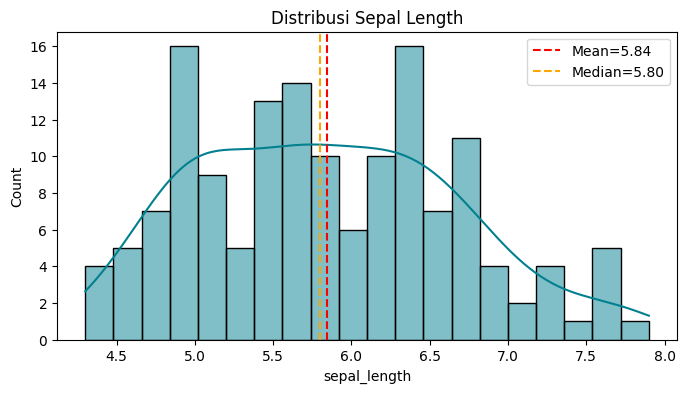

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))

# Plot Histogram dan KDE
sns.histplot(df['sepal_length'], kde=True, color='#028090', bins=20, ax=ax)

# Garis Mean
ax.axvline(df['sepal_length'].mean(), color='red', linestyle='--',
           label=f"Mean={df['sepal_length'].mean():.2f}")

# Garis Median
ax.axvline(df['sepal_length'].median(), color='orange', linestyle='--',
           label=f"Median={df['sepal_length'].median():.2f}")

ax.set_title('Distribusi Sepal Length')
ax.legend()
plt.show()

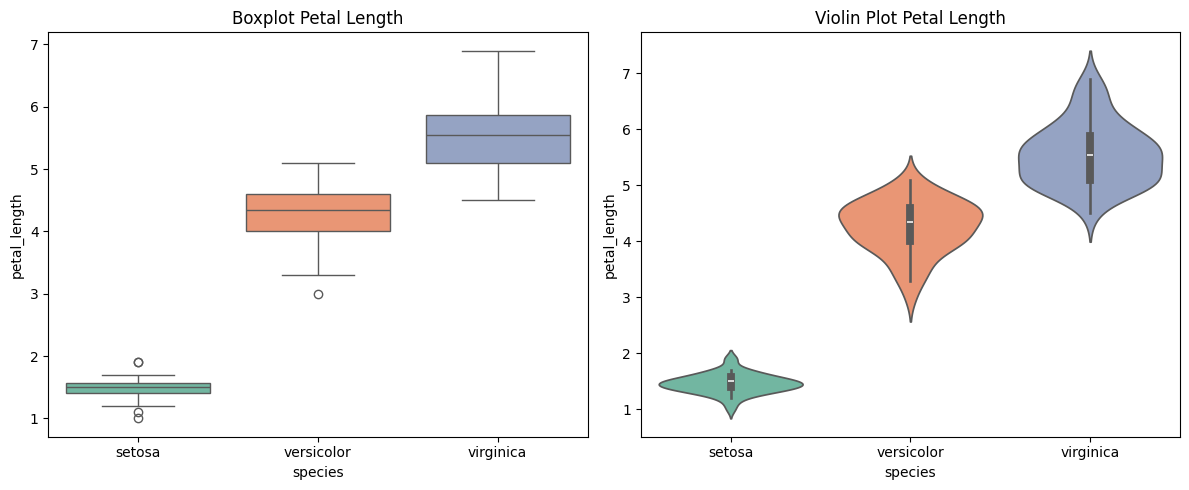

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Boxplot
sns.boxplot(data=df, x='species', y='petal_length', palette='Set2', hue='species', legend=False, ax=axes[0])
axes[0].set_title('Boxplot Petal Length')

# 2. Violin Plot
sns.violinplot(data=df, x='species', y='petal_length', palette='Set2', inner='box', hue='species', legend=False, ax=axes[1])
axes[1].set_title('Violin Plot Petal Length')

plt.tight_layout()
plt.show()

In [7]:
print("=== MATRIKS KORELASI PEARSON ===")
corr = df.drop('species', axis=1).corr(method='pearson')
print(corr.round(3))
print("\n")

# Mencari pasangan korelasi tertinggi secara otomatis
mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)
max_pair = corr_masked.stack().idxmax()

print(f'Korelasi tertinggi: {max_pair} = {corr.loc[max_pair]:.3f}')

=== MATRIKS KORELASI PEARSON ===
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000


Korelasi tertinggi: ('petal_width', 'petal_length') = 0.963


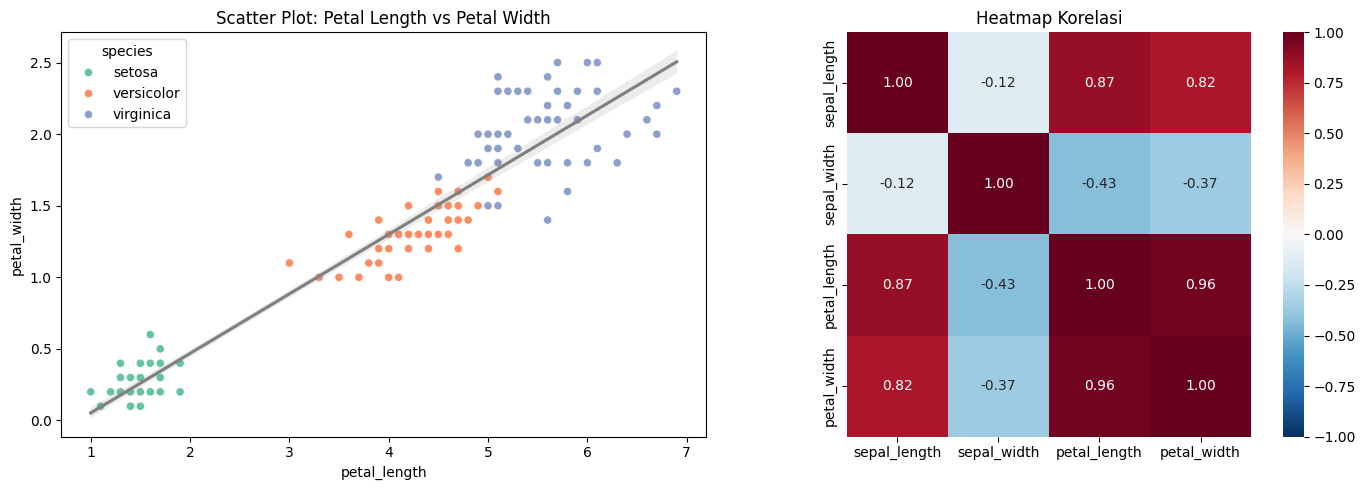

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Scatter Plot (Petal Length vs Petal Width)
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', palette='Set2', ax=axes[0])
sns.regplot(data=df, x='petal_length', y='petal_width', scatter=False, color='gray', ax=axes[0])
axes[0].set_title('Scatter Plot: Petal Length vs Petal Width')

# 2. Heatmap Korelasi
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title('Heatmap Korelasi')

plt.tight_layout()
plt.show()